## Using pretrained AI

Classic chemometrics (PLS, PCR, MCR-ALS, ...) is built for the case where you have a modest number of calibration samples and a rich, structured signal per sample (a spectrum, a spectral image cube). Deep learning is built for the opposite case: huge datasets, raw pixels, and no hand-crafted features. Most agri-food imaging datasets sit in between - a few dozen to a few hundred samples, RGB/X-ray/hyperspectral images, and a reference value from a lab measurement (fat %, fibrousness, texture, ...). Training a CNN from scratch on that is a recipe for overfitting.

Pretrained AI models solve a different problem than the one we have but we can still borrow their internal representations. A network like ResNet, trained on millions of natural images, has learned a general-purpose way to describe visual texture, shape and structure. We can reuse that as a feature extractor, then hand the resulting features to the multivariate regression tools you already trust (PLS, cross-validation, multiblock fusion) instead of retraining a deep network ourselves.

This notebook walks through that idea end to end, across three imaging modalities:

1. **What pretrained models already do out of the box** - segmentation & detection, and why they don't just work on just any images (domain gap).
2. **Turning pixels into features** - deep feature extraction with ResNet.
3. **Training PLS models on ResNet-18 features** - deep features + PLS, with proper cross-validated selection of the number of latent variables (LVs).
4. **Combining ResNet-18 features with spectral signal** - combining ResNet spatial features with the spectral signal using approaches we've explored in data fusion notebook, and comparing fused vs. single-block models.
6. **Discussion** — where this approach helps, and where it doesn't.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Define the path to your data and result folders in Google Drive
# data_path="data"
data_path = '/content/drive/MyDrive/data/using_pretrained_ai'

In [ ]:
# install dependencies
!pip install -q numpy pandas matplotlib tensorflow scikit-learn scipy ultralytics segment-anything supervision pysptools

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda:0


In [3]:
rgb_img_path = f"{data_path}/1A_rgb.png"
rgb_img = cv2.imread(rgb_img_path)

### Detection with YOLO

Unlike SAM, YOLO needs to have seen a class during training to recognize it. Let's try it on the same image, then on something it was never trained for.


0: 608x640 2 ovens, 51.4ms
Speed: 11.8ms preprocess, 51.4ms inference, 216.8ms postprocess per image at shape (1, 3, 608, 640)


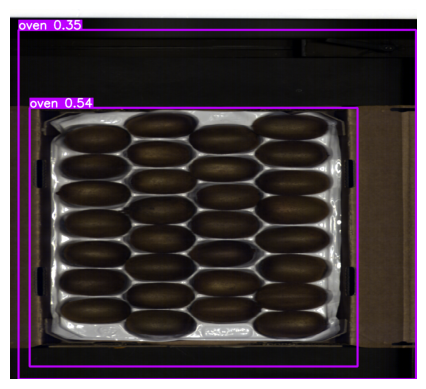

oven: 0.54
oven: 0.35


In [4]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')

results = yolo_model(rgb_img)
annotated_frame = results[0].plot()
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_frame)
plt.axis('off')
plt.show()

for box in results[0].boxes:
    cls = int(box.cls[0])
    label = yolo_model.names[cls]
    conf = float(box.conf[0])
    print(f"{label}: {conf:.2f}")

That didn't work because YOLO's pretrained weights only recognize the ~80 everyday object classes it was trained on (person, car, dog, ...) - not the specific classes we have in our picture. Let's confirm that by trying it on carrots (existing classification class in the dataset):


0: 480x640 1 person, 11 carrots, 296.8ms
Speed: 14.2ms preprocess, 296.8ms inference, 4.3ms postprocess per image at shape (1, 3, 480, 640)


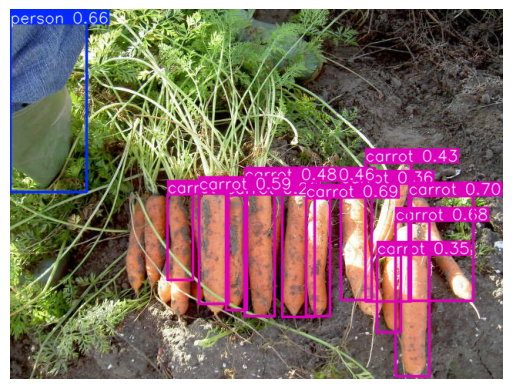

carrot: 0.70
carrot: 0.69
carrot: 0.68
person: 0.66
carrot: 0.59
carrot: 0.48
carrot: 0.46
carrot: 0.43
carrot: 0.36
carrot: 0.35
carrot: 0.26
carrot: 0.25


In [5]:
carrot_img = cv2.imread(f"{data_path}/carrots.jpg")

results = yolo_model(carrot_img)
annotated_frame = results[0].plot()
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_frame)
plt.axis('off')
plt.show()

for box in results[0].boxes:
    cls = int(box.cls[0])
    label = yolo_model.names[cls]
    conf = float(box.conf[0])
    print(f"{label}: {conf:.2f}")

### Segmentation with SAM

SAM segments *any* image into coherent regions - it doesn't need to know what a 'pork belly' or a 'carrot' is to find its boundaries.

In [6]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import supervision as sv

def detect_with_sam(rgb_img):
    MODEL_TYPE = "vit_l"
    SAM_CHECKPOINT_PATH = data_path + "/sam_vit_l_0b3195.pth"

    sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_CHECKPOINT_PATH).to(device=DEVICE)
    mask_generator = SamAutomaticMaskGenerator(sam)
    sam_result = mask_generator.generate(rgb_img)
    return sv.Detections.from_sam(sam_result=sam_result)

sam_detections = detect_with_sam(rgb_img)

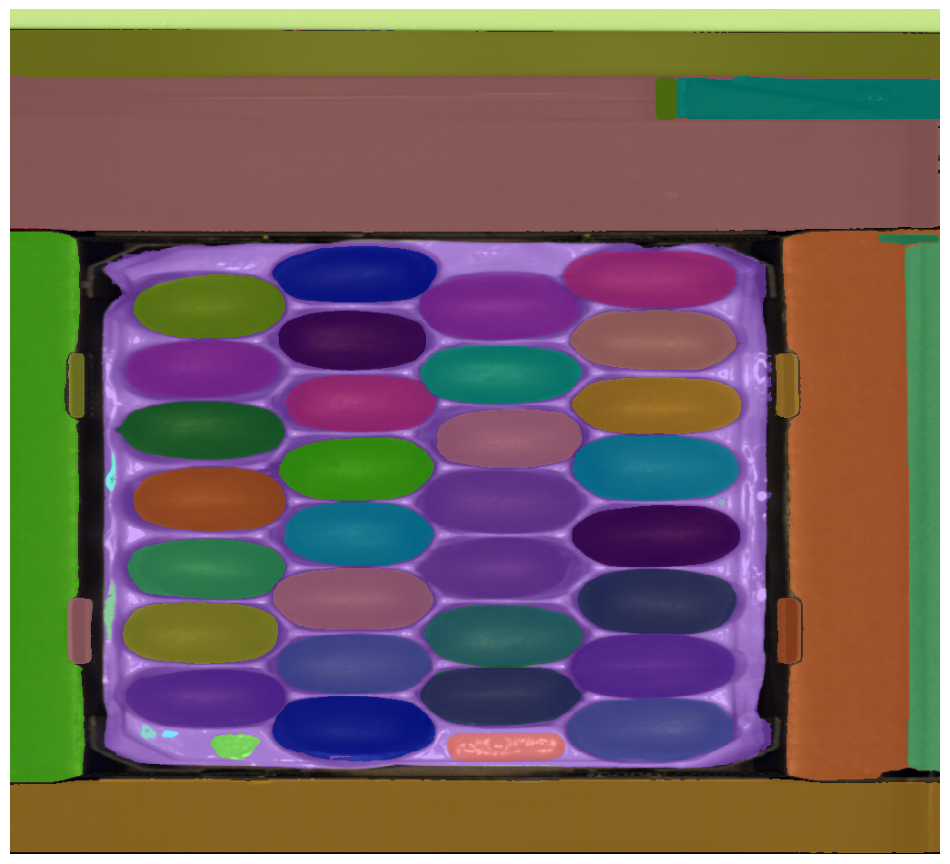

In [7]:
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
sam_result = mask_annotator.annotate(scene=rgb_img.copy(), detections=sam_detections)
sv.plot_image(image=sam_result)

This is the key limitation: off-the-shelf segmentation/detection models are great generalists for generic visual structure, but they are not calibrated to our quantities
of interest (fibrousness, fat %, texture) and often don't even recognize our objects. Retraining them from scratch would need far more labeled images than a typical chemometrics dataset has.

The trick used for the rest of this notebook: don't ask a pretrained network for its final predictions - ask it for its internal representation instead, and let PLS regression or other small model, trained on our own (small) calibration set, do the quantitative mapping to the property we actually care about.

## Pulling out a single kiwi image with SAM + spectra

SAM's masks by themselves don't know what a kiwi is - we already saw that ambiguity above (tray compartments, shadows, and fruit all look like "a region" to SAM). Last year's learning material `loading_data` notebook was focussed on post-processing of SAM results: pick one mask we're sure is kiwi, average its spectrum, then keep any other mask whose spectrum is close enough (based on Spectral Angle Mapper distance).

Below we will look at a simpified pipeline from that notebook.

### Load the hyperspectral cube and a saved kiwi spectrum

SAM only ever sees the RGB rendering, but telling kiwi apart from the plastic tray needs the actual spectral signal. We reload the hyperspectral cube that `1A_rgb.png` was rendered from, and load one average kiwi spectrum that we already saved earlier (instead of hunting for a reference mask by hand, like `loading_data.ipynb` does).

In [8]:
import scipy.io

mat = scipy.io.loadmat(f"{data_path}/1A.mat")
hyperspectral_img = mat["img"]
wavelengths = mat["Wavelength"]

# A single average kiwi spectrum
kiwi_reference_spectrum = np.loadtxt(f"{data_path}/kiwi_spectrum.csv", delimiter=",")
red, green, blue = 575, 535, 445

def find_closest_index(target, array):
    return np.abs(np.asarray(array) - target).argmin()

def to_pseudo_rgb(cube, wavelengths):
    idx = [find_closest_index(w, wavelengths) for w in (red, green, blue)]
    rgb = np.stack([cube[:, :, i] for i in idx], axis=-1)
    norm = np.empty_like(rgb, dtype=np.float32)
    for i in range(3):
        channel = rgb[:, :, i]
        vmin, vmax = np.percentile(channel, 1), np.percentile(channel, 99)
        norm[:, :, i] = np.clip((channel - vmin) / (vmax - vmin), 0, 1)
    return (norm * 255).astype(np.uint8)

### Keep only plausible-sized masks

SAM proposes far more regions than there are kiwis on the tray - shadows, tray edges, overlapping fragments. A quick size filter clears most of that out before we even look at spectra.

In [9]:
min_height, max_height = 50, 120
min_width, max_width = 150, 210

def filter_masks_by_size(detections):
    filtered_masks, filtered_xyxy = [], []
    for xyxy, mask in zip(detections.xyxy, detections.mask):
        y_coords, x_coords = np.where(mask)
        height = y_coords.max() - y_coords.min() + 1
        width = x_coords.max() - x_coords.min() + 1
        if min_height <= height <= max_height and min_width <= width <= max_width:
            filtered_masks.append(mask)
            filtered_xyxy.append(xyxy)
    return sv.Detections(xyxy=np.array(filtered_xyxy), mask=np.stack(filtered_masks))

filtered_detections = filter_masks_by_size(sam_detections)
print(f"{len(filtered_detections.mask)} masks left after size filtering")

30 masks left after size filtering


### Find the masks whose spectrum matches kiwi best

In case simple tricks with size filtering do not suit your suitcase, you can also average the spectrum of pixels within the mask and compare it to `kiwi_reference_spectrum` with the Spectral Angle Mapper distance - the closer to 0, the more alike. (Confusingly, "SAM" here means Spectral Angle Mapper, not Segment Anything - we import it under a different name to keep the two apart.) 

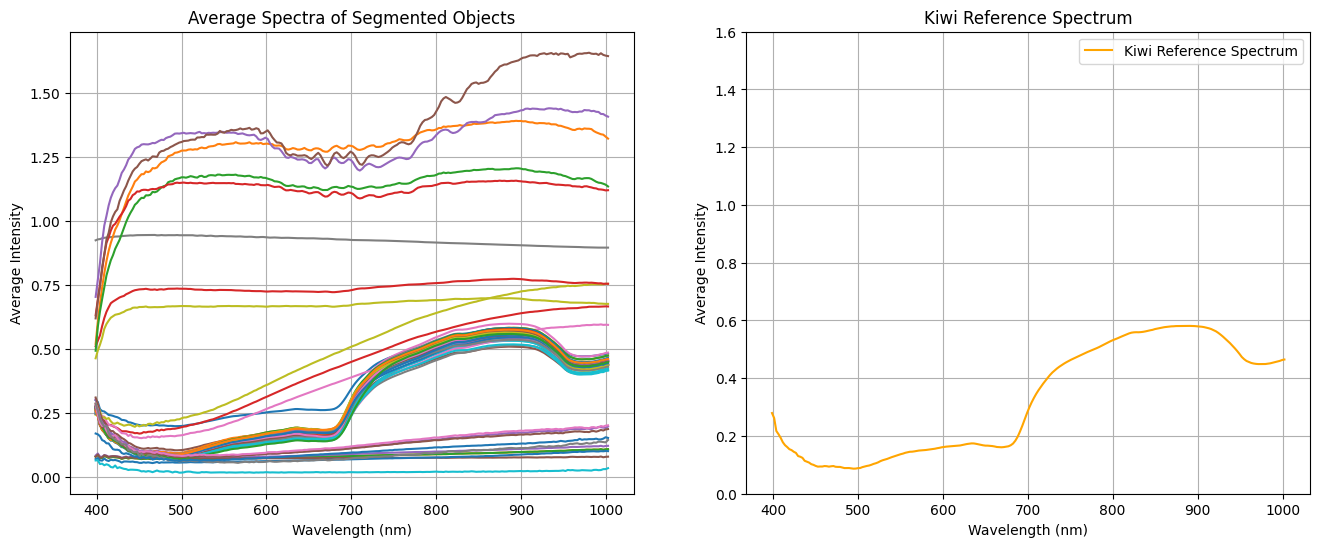

In [13]:
# plot average spectra of all masks on the left and the average spectrum of the reference kiwi on the right on the same y axis
plt.figure(figsize=(16, 6))

for i, mask in enumerate(sam_detections.mask):
    masked_pixels = hyperspectral_img[mask]
    avg_spectrum = masked_pixels.mean(axis=0)

    # Plot the average spectrum for this object
    plt.subplot(1, 2, 1)
    plt.plot(wavelengths, avg_spectrum)
    
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Average Intensity")
    plt.title("Average Spectra of Segmented Objects")
    plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(wavelengths, kiwi_reference_spectrum, color='orange', label='Kiwi Reference Spectrum')
ax = plt.gca()
ax.set_ylim([0, 1.6])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Average Intensity")
plt.title("Kiwi Reference Spectrum")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
from pysptools.distance import SAM as spectral_angle

cutoff_score = 0.035 # had to search for a good cutoff score
def filter_masks_by_spectrum(detections):
    filtered_masks, filtered_xyxy = [], []
    for xyxy, mask in zip(detections.xyxy, detections.mask):
        avg_spectrum = hyperspectral_img[mask].mean(axis=0)
        score = spectral_angle(kiwi_reference_spectrum, avg_spectrum)
        if score < cutoff_score:
            filtered_masks.append(mask)
            filtered_xyxy.append(xyxy)
    return sv.Detections(xyxy=np.array(filtered_xyxy), mask=np.stack(filtered_masks))

filtered_detections = filter_masks_by_spectrum(sam_detections)
print(f"{len(filtered_detections.mask)} masks left after spectrum filtering")

30 masks left after spectrum filtering


### Crop and plot that one kiwi

Based off that filtering step you can now select separate kiwis and to afterwards extract the respective ResNet-18 features (we'll reshape it to 256x256 to fit input shape)

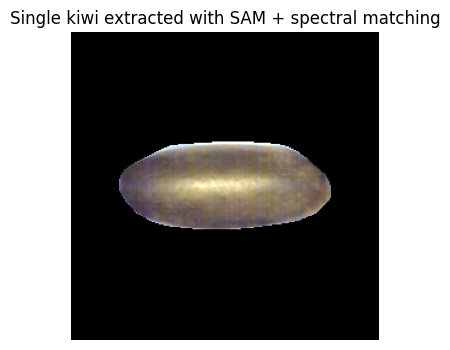

In [ ]:
mask = filtered_detections.mask[np.random.randint(len(filtered_detections.mask))]  
y_coords, x_coords = np.where(mask)
y_min, y_max = y_coords.min(), y_coords.max()
x_min, x_max = x_coords.min(), x_coords.max()

# crop the small region first
region = hyperspectral_img[y_min:y_max+1, x_min:x_max+1, :]
mask_crop = mask[y_min:y_max+1, x_min:x_max+1]

kiwi_region = np.zeros_like(region)
kiwi_region[mask_crop] = region[mask_crop]

# Bounding box dimensions
width = x_max - x_min + 1
height = y_max - y_min + 1

if width>256:
    print(f"Warning: Detected kiwi has width {width} which exceeds 256 pixels.")
if height>256:
    print(f"Warning: Detected kiwi has height {height} which exceeds 256 pixels.")

kiwi_rgb = to_pseudo_rgb(kiwi_region, wavelengths)

#pad to size 256x256 with kiwi fruit in the center and black background
padded_kiwi_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
padded_kiwi_rgb[(256 - kiwi_rgb.shape[0]) // 2:(256 + kiwi_rgb.shape[0]) // 2,
                (256 - kiwi_rgb.shape[1]) // 2:(256 + kiwi_rgb.shape[1]) // 2, :] = kiwi_rgb

plt.figure(figsize=(4, 4))
plt.imshow(padded_kiwi_rgb)
plt.title("Single kiwi extracted with SAM + spectral matching")
plt.axis("off")
plt.show()

Off-the-shelf segmentation only gives you regions, not identities - SAM can't tell a kiwi from a tray compartment on its own.
A single saved reference spectrum, compared via Spectral Angle Mapper distance, is enough to pick the matching object out of SAM's masks - no manual mask-picking needed once that reference exists.

## Deep feature extraction (ResNet-18) and training models based off those

A CNN like ResNet, trained on ImageNet, ends in a classification layer over 1000 object classes — not useful to us directly. But verything before that layer is a rich, general-purpose description of image texture, shape and structure, compressed into a single vector per image (512 dimensions for ResNet-18, 2048 for ResNet-50).

We treat that vector the same way we'd treat a spectrum: as a fixed-length numerical "fingerprint" of the sample, ready to be fed into PLS.

In [29]:
print("Loading ResNet-18...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the final FC layer to get the 512-dim feature vector
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor.eval()

# Define ImageNet Preprocessing (Equivalent to MATLAB's normalization step)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # ImageNet RGB means
                         std=[0.229, 0.224, 0.225])  # ImageNet RGB stds
])

Loading ResNet-18...


In [30]:
def extract_deep_features(image_paths, batch_size=16):
    """Extracts 512-D deep features from a list of image paths."""
    features = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    feature_extractor.to(device)
    
    # Process in batches
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = []
        for path in batch_paths:
            img = Image.open(path).convert('RGB')
            batch_imgs.append(preprocess(img))
        
        batch_tensor = torch.stack(batch_imgs).to(device)
        
        with torch.no_grad():
            # Forward pass
            output = feature_extractor(batch_tensor)
            # Flatten from (N, 512, 1, 1) to (N, 512)
            batch_features = output.view(output.size(0), -1).cpu().numpy()
            features.append(batch_features)
            
    return np.vstack(features)

It's worth *seeing* a feature vector at least once before trusting it: it won't mean anything visually, but its shape and the fact that different images give visibly different vectors is a
useful sanity check.

Extracted 2 feature vectors of length 512


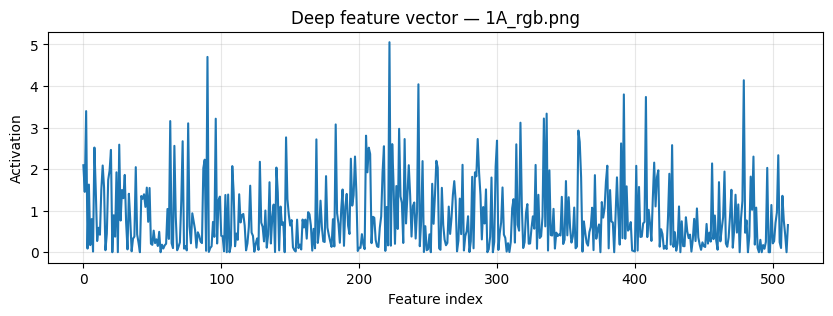

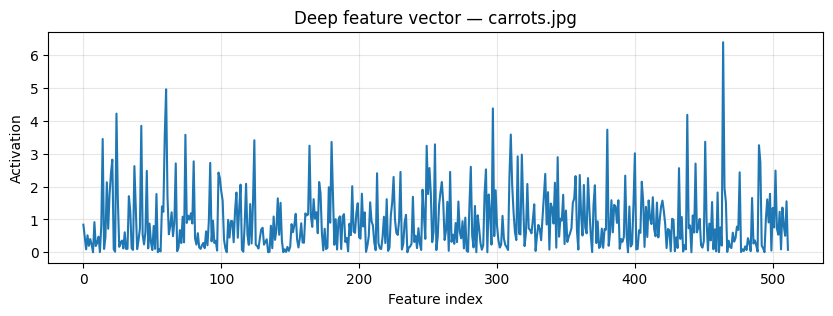

In [31]:
sample_paths = [rgb_img_path, f"{data_path}/carrots.jpg"]
sample_features = extract_deep_features(sample_paths)
print(f"Extracted {sample_features.shape[0]} feature vectors of length {sample_features.shape[1]}")

for path, feat in zip(sample_paths, sample_features):
    plt.figure(figsize=(10, 3))
    plt.plot(feat)
    plt.title(f"Deep feature vector — {os.path.basename(path)}")
    plt.xlabel("Feature index")
    plt.ylabel("Activation")
    plt.grid(alpha=0.3)
    plt.show()

### PLS on deep features 

For the exercise below we've already prepared a set of images of pork belly images.

In [32]:
import scipy.io
from sklearn.preprocessing import StandardScaler

filepath = f"{data_path}/spatial_spectra_pig.mat"
mat = scipy.io.loadmat(filepath)
print(mat["spatial"].shape)
print(mat["spectral"].shape)
print(mat["ref"].shape)

mat.keys()

(182, 512)
(182, 300)
(182, 1)


dict_keys(['__header__', '__version__', '__globals__', 'ref', 'spatial', 'spectral'])

In [33]:
X_spatial = mat["spatial"]
X_spectral = mat["spectral"]
y = mat["ref"]
max_lv = 20
rmsecv_scores = []

In [34]:
for lv in range(1, max_lv + 1):
    pls = PLSRegression(n_components=lv)
    # 5-fold cross-validation
    y_pred_cv = cross_val_predict(pls, X_spatial, y, cv=5)
    rmsecv = np.sqrt(mean_squared_error(y, y_pred_cv))
    rmsecv_scores.append(rmsecv)

optimal_lv = np.argmin(rmsecv_scores) + 1

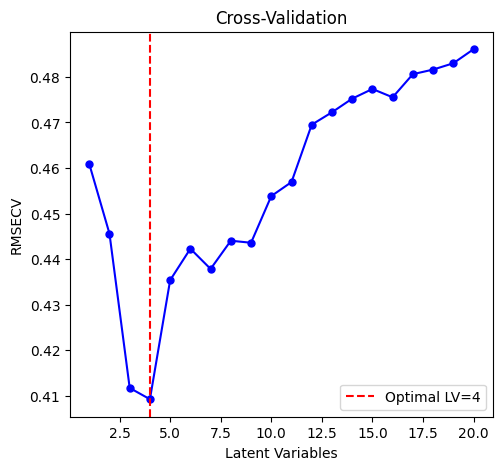

In [35]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, max_lv + 1), rmsecv_scores, '.-b', markersize=10)
plt.axvline(optimal_lv, color='r', linestyle='--', label=f'Optimal LV={optimal_lv}')
plt.xlabel('Latent Variables')
plt.ylabel('RMSECV')
plt.title('Cross-Validation')
plt.legend()

In [36]:
pls_final = PLSRegression(n_components=optimal_lv)
pls_final.fit(X_spatial, y)
y_pred = pls_final.predict(X_spatial).flatten()

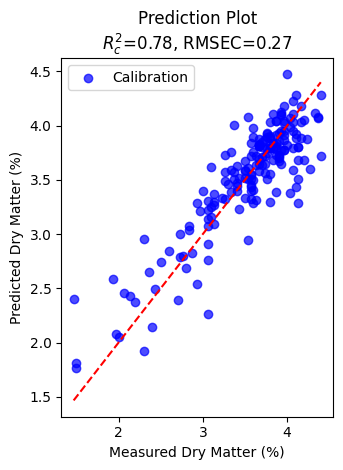

In [37]:
rmsec = np.sqrt(mean_squared_error(y, y_pred))
r2c = r2_score(y, y_pred)

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred, alpha=0.7, c='blue', label='Calibration')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.title(f'Prediction Plot\n$R^2_c$={r2c:.2f}, RMSEC={rmsec:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

### Fusion of spectral and spatial features

Let's try to combine both spectral and spatial features in the way we worked with them in the data fusion notebook

In [38]:
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import tensorflow as tf

SPATIAL_FILTER_SIZE = 5
SPECTRAL_FILTER_SIZE = 5
L2_BETA = 0.001
initial_lr = 0.001

from sklearn.model_selection import train_test_split

# First split: train (80%) and temp (20%)
X_spatial_train, X_spatial_temp, X_spectral_train, X_spectral_temp, y_train, y_temp = train_test_split(
    X_spatial,
    X_spectral,
    y,
    test_size=0.2,
    random_state=42
)

# Second split: temp -> validation (10%) and test (10%)
X_spatial_val, X_spatial_test, X_spectral_val, X_spectral_test, y_val, y_test = train_test_split(
    X_spatial_temp,
    X_spectral_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print(f"Training set size: {X_spatial_train.shape[0]}")
print(f"Validation set size: {X_spatial_val.shape[0]}")
print(f"Test set size: {X_spatial_test.shape[0]}")


spectral_scaler = StandardScaler()
X_spectral_train = spectral_scaler.fit_transform(X_spectral_train)
X_spectral_val = spectral_scaler.transform(X_spectral_val)
X_spectral_test = spectral_scaler.transform(X_spectral_test)

spatial_model_input = Input(shape=(X_spatial_train.shape[1], 1), name='spatial_input')
x_spatial = Conv1D(filters=1, kernel_size=SPATIAL_FILTER_SIZE, strides=1, 
                   activation='elu', kernel_regularizer=l2(L2_BETA))(spatial_model_input)
x_spatial = Conv1D(filters=1, kernel_size=SPATIAL_FILTER_SIZE, strides=1, 
                   activation='elu', kernel_regularizer=l2(L2_BETA))(x_spatial)
x_spatial_flat = Flatten()(x_spatial)
x_spatial_dense = Dense(36, activation='elu', kernel_regularizer=l2(L2_BETA))(x_spatial_flat)
x_spatiall_dense = Dense(18, activation='elu', kernel_regularizer=l2(L2_BETA))(x_spatial_dense)
spatial_output = Dense(1, activation='linear', name='spatial_output')(x_spatial_dense)

spatial_only_model = Model(inputs=spatial_model_input, outputs=spatial_output, name='Spatial_Only_CNN')
spatial_only_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr), loss='mse')

Training set size: 145
Validation set size: 18
Test set size: 19


I0000 00:00:1788951487.897499    2299 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8753 MB memory:  -> device: 0, name: NVIDIA RTX A5500 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [39]:
print("\nTraining Spatial-Only Model...")
BATCH_SIZE = 32

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Shapes of training and validation data:")
print(f"Training data shape: {X_spatial_train.shape}")
print(f"Validation data shape: {X_spatial_val.shape}")

history_spatial= spatial_only_model.fit(
    x=X_spatial_train, y=y_train,
    validation_data=(X_spatial_val, y_val),
    epochs=150, batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=0), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25, min_lr=1e-6, verbose=1)],
    verbose=1
)


Training Spatial-Only Model...
Shapes of training and validation data:
Training data shape: (145, 512)
Validation data shape: (18, 512)
Epoch 1/150


1/5 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - loss: 17.4664

I0000 00:00:1788951538.527601   25147 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 675ms/step - loss: 7.3200 - val_loss: 0.7524 - learning_rate: 0.0010
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2506 - val_loss: 3.0376 - learning_rate: 0.0010
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7287 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4870 - val_loss: 0.8141 - learning_rate: 0.0010
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8989 - val_loss: 0.5158 - learning_rate: 0.0010
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3705 - val_loss: 0.3819 - learning_rate: 0.0010
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3364 - val_loss: 0.6060 - learning_rate: 0.0010
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3504 - val_loss: 0.3465 - learning_rate: 0.0010
Epoch 9/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2219 - val_loss: 0.2846 - learning_rate: 0.0010
Epoch 10/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0

In [40]:
spectral_model_input = Input(shape=(X_spectral_train.shape[1], 1), name='spectral_input')
x_spectral = Conv1D(filters=8, kernel_size=SPECTRAL_FILTER_SIZE, strides=1,
                   activation='elu', kernel_regularizer=l2(L2_BETA))(spectral_model_input)
x_spectral = Conv1D(filters=4, kernel_size=SPECTRAL_FILTER_SIZE, strides=1,
                   activation='elu', kernel_regularizer=l2(L2_BETA))(x_spectral)
x_spectral_flat = Flatten()(x_spectral)
x_spectral_dense = Dense(36, activation='elu', kernel_regularizer=l2(L2_BETA))(x_spectral_flat)
x_spectral_dense = Dense(18, activation='elu', kernel_regularizer=l2(L2_BETA))(x_spectral_dense)
spectral_output = Dense(1, activation='linear', name='spectral_output')(x_spectral_dense)

spectral_only_model = Model(inputs=spectral_model_input, outputs=spectral_output, name='Spectral_Only_CNN')
spectral_only_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr), loss='mse')

In [41]:
print("Training Spectral-Only Model...")
history_spectral = spectral_only_model.fit(
    x=X_spectral_train, y=y_train,
    validation_data=(X_spectral_val, y_val),
    epochs=300, batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)

Training Spectral-Only Model...
Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 375ms/step - loss: 8.7938 - val_loss: 3.1913 - learning_rate: 0.0010
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.7905 - val_loss: 2.3438 - learning_rate: 0.0010
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.6793 - val_loss: 1.4357 - learning_rate: 0.0010
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3962 - val_loss: 1.5882 - learning_rate: 0.0010
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8482 - val_loss: 1.4345 - learning_rate: 0.0010
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7084 - val_loss: 1.8617 - learning_rate: 0.0010
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5921 - val_loss: 1.1647 - learning_rate: 0.0010
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4527 - val_loss: 0.6186 - learning_rate: 0.0010
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3624 - val_loss: 0.5184 - learning_rate: 0.

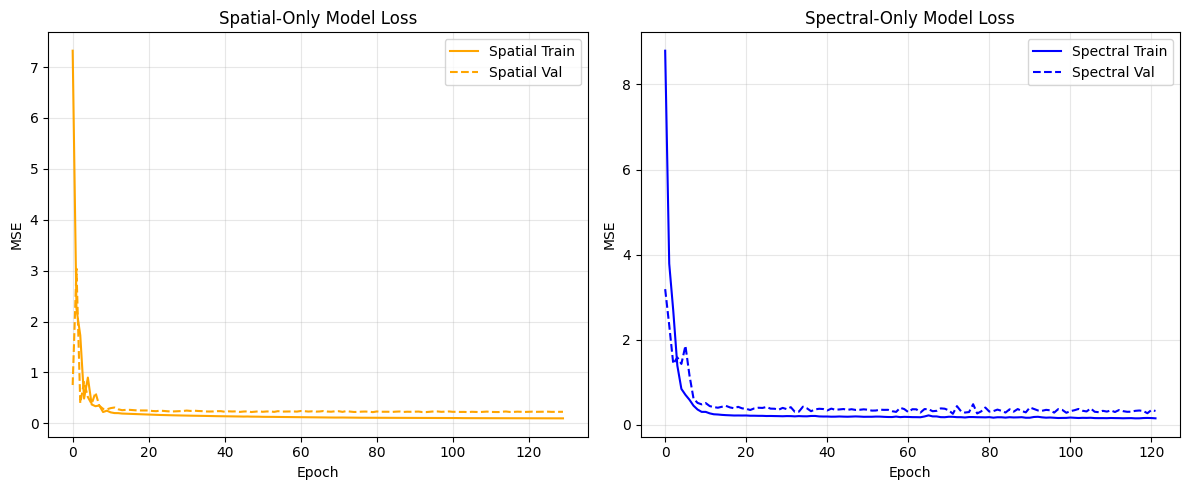

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_spatial.history['loss'], label='Spatial Train', color='orange')
plt.plot(history_spatial.history['val_loss'], label='Spatial Val', color='orange', linestyle='--')
plt.title('Spatial-Only Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_spectral.history['loss'], label='Spectral Train', color='blue')
plt.plot(history_spectral.history['val_loss'], label='Spectral Val', color='blue', linestyle='--')
plt.title('Spectral-Only Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# Validation set predictions (used for determining fusion weights)
y_val_pred_spatial = spatial_only_model.predict(X_spatial_val, verbose=0).ravel()
y_val_pred_spectral = spectral_only_model.predict(X_spectral_val, verbose=0).ravel()

# Test set predictions
y_test_pred_spatial = spatial_only_model.predict(X_spatial_test, verbose=0).ravel()
y_test_pred_spectral = spectral_only_model.predict(X_spectral_test, verbose=0).ravel()

In [44]:
# Evaluate individual models on test set
rmse_spatial = np.sqrt(mean_squared_error(y_test, y_test_pred_spatial))
r2_spatial = r2_score(y_test, y_test_pred_spatial)

rmse_spectral = np.sqrt(mean_squared_error(y_test, y_test_pred_spectral))
r2_spectral = r2_score(y_test, y_test_pred_spectral)
print("\n--- Individual Models Test Performance ---")
print(f"Spatial-Only CNN -> RMSE: {rmse_spatial:.3f}, R²: {r2_spatial:.3f}")
print(f"Spectral-Only CNN   -> RMSE: {rmse_spectral:.3f}, R²: {r2_spectral:.3f}")


--- Individual Models Test Performance ---
Spatial-Only CNN -> RMSE: 0.451, R²: 0.480
Spectral-Only CNN   -> RMSE: 0.275, R²: 0.807


In [45]:
# Strategy 1: simple averaging
y_test_pred_simple_avg = (y_test_pred_spatial + y_test_pred_spectral) / 2.0

rmse_simple_avg = np.sqrt(mean_squared_error(y_test, y_test_pred_simple_avg))
r2_simple_avg = r2_score(y_test, y_test_pred_simple_avg)

print(f"High-Level Fusion: Simple Averaging")
print(f"RMSE:{rmse_simple_avg:.3f} % DM")
print(f"R²:{r2_simple_avg:.3f}")

High-Level Fusion: Simple Averaging
RMSE:0.309 % DM
R²:0.755


In [46]:
#  Weighted averaging via Linear Regression Meta-Learner
from sklearn.linear_model import LinearRegression

y_train_pred_spatial = spatial_only_model.predict(X_spatial_train, verbose=0).ravel()
y_train_pred_spectral = spectral_only_model.predict(X_spectral_train, verbose=0).ravel()

X_train_meta = np.column_stack((y_train_pred_spatial, y_train_pred_spectral))
meta_learner = LinearRegression()
meta_learner.fit(X_train_meta, y_train)

# The learned weights (coefficients) show how much each model is "voted" for
print(f"\nMeta-learner weights (Spatial, Spectral): {meta_learner.coef_}")
print(f"Meta-learner intercept: {meta_learner.intercept_}")


Meta-learner weights (Spatial, Spectral): [[    0.82515     0.20827]]
Meta-learner intercept: [  -0.079558]


In [47]:
# Apply meta-learner to test set predictions
X_test_meta = np.column_stack((y_test_pred_spatial, y_test_pred_spectral))
y_test_pred_weighted = meta_learner.predict(X_test_meta)

rmse_weighted = np.sqrt(mean_squared_error(y_test, y_test_pred_weighted))
r2_weighted = r2_score(y_test, y_test_pred_weighted)

print(f"\n--- High-Level Fusion: Weighted Averaging (Stacking) ---")
print(f"RMSE: {rmse_weighted:.3f} % DM")
print(f"R²:   {r2_weighted:.3f}")


--- High-Level Fusion: Weighted Averaging (Stacking) ---
RMSE: 0.383 % DM
R²:   0.626


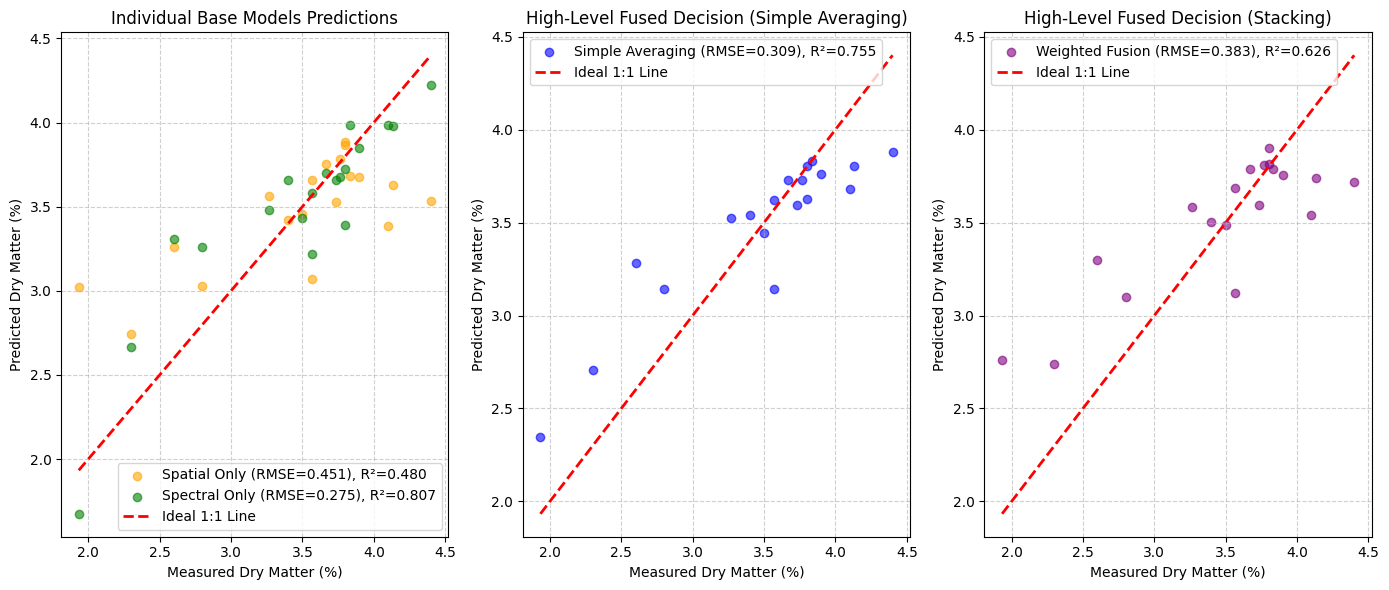

In [48]:
# Plot predictions vs actual values for high-level fusion
min_val = min(np.min(y_test), np.min(y_test_pred_weighted))
max_val = max(np.max(y_test), np.max(y_test_pred_weighted))

plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_test_pred_spatial, alpha=0.6, color='orange', label=f'Spatial Only (RMSE={rmse_spatial:.3f}), R²={r2_spatial:.3f}')
plt.scatter(y_test, y_test_pred_spectral, alpha=0.6, color='green', label=f'Spectral Only (RMSE={rmse_spectral:.3f}), R²={r2_spectral:.3f}')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('Individual Base Models Predictions')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_test_pred_simple_avg, alpha=0.6, color='blue', label=f'Simple Averaging (RMSE={rmse_simple_avg:.3f}), R²={r2_simple_avg:.3f}')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('High-Level Fused Decision (Simple Averaging)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_test_pred_weighted, alpha=0.6, color='purple', label=f'Weighted Fusion (RMSE={rmse_weighted:.3f}), R²={r2_weighted:.3f}')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 1:1 Line')
plt.title('High-Level Fused Decision (Stacking)')
plt.xlabel('Measured Dry Matter (%)')
plt.ylabel('Predicted Dry Matter (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Takeaways

- Typical tasks in chemometrics rarely can find pre-trained AI models that researchers can use out of the box.
- Most images that these models are trained on are very different from the images we meet in hyperspectral measurements and moreover the tasks these models perform are different from the ones we are trying to accomplish.
- Internal representations of those big deep learning models is something we can borrow and use in predicting the properties of interest (fat, fibrousness, dry matter). 